
$\text{Janitza Current} = k I_{sm}  + I_{um} + \text{NTL}+ \sigma $

Where $k$ is CT scaling factor, $I_{sm}$ is the smart meter sum, $I_{um}$ is the unmetered load,NTL is the non techinal losses and $\sigma$ is the noise

In [23]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math

FREQ = pd.Timedelta(minutes=15)

def parse_dnr(d): 
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)


def make_expected_grid(df, freq=FREQ):
    """Build full expected 15-min grid per (substation, transformer) over its observed span."""
    out = []
    for (sid, tr), g in df.groupby(["substation_id", "transformer"]):
        t0 = g["ts"].min()
        t1 = g["ts"].max()
        grid = pd.date_range(t0, t1, freq=freq)
        out.append(pd.DataFrame({"substation_id": sid, "transformer": tr, "ts": grid}))
    return pd.concat(out, ignore_index=True)


def compute_ct_diagnostics(
    merged: pd.DataFrame,
    min_points: int = 50,
    min_current: float = 5.0,
) -> pd.DataFrame:
    """
    Per-(substation, transformer) diagnostics to detect CT scaling vs unmetered load.

    Expects columns in merged:
      substation_id, transformer, ts,
      I_total_sm, I_total_jn, n_mps, per_completed

    Assumes:
      - Janitza should be an upper bound for true current
        → in a physically consistent situation, I_total_sm <= I_total_jn
        (ignoring noise / mapping mistakes).
    """
    rows = []

    required = {"substation_id", "transformer", "I_total_sm", "I_total_jn"}
    missing = required - set(merged.columns)
    if missing:
        raise KeyError(f"compute_ct_diagnostics: merged is missing required columns: {sorted(missing)}")

    # Normalize transformer just in case
    m = merged.copy()
    m["transformer"] = m["transformer"].astype(str).str.strip().str.lower()

    for (sid, tr), g in m.groupby(["substation_id", "transformer"], dropna=False):
        g = g.copy()

        # Filter out very low currents (ratios get crazy near zero)
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if len(g) < min_points:
            continue  # not enough data

        x = g["I_total_sm"].to_numpy()
        y = g["I_total_jn"].to_numpy()

        # --- 1) Physical sanity: how often is SMD > Janitza? ---
        sm_gt_jn = (g["I_total_sm"] > g["I_total_jn"])
        frac_sm_gt_jn = float(sm_gt_jn.mean())

        # --- 2) Unconstrained linear fit: y ≈ alpha * x + beta ---
        alpha_ls, beta = np.polyfit(x, y, 1)

        y_pred = alpha_ls * x + beta
        ss_res = float(np.sum((y - y_pred) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Correlation (shape similarity)
        corr = g["I_total_jn"].corr(g["I_total_sm"])

        # --- 3) Ratio-based view: y/x distribution ---
        ratio = (g["I_total_jn"] / g["I_total_sm"]).replace([np.inf, -np.inf], np.nan).dropna()
        ratio_median = float(ratio.median()) if not ratio.empty else np.nan
        ratio_std = float(ratio.std()) if not ratio.empty else np.nan
        ratio_min = float(ratio.min()) if not ratio.empty else np.nan
        ratio_p05 = float(ratio.quantile(0.05)) if len(ratio) > 0 else np.nan

        # --- 4) "CT scaling" factor under your physical constraint ---
        if float(np.sum(x**2)) > 0:
            alpha0 = float(np.sum(x * y) / np.sum(x**2))
        else:
            alpha0 = np.nan

        alpha_max_phys = ratio_p05  # use ratio_min if you want strict
        if (not np.isnan(alpha0)) and (not np.isnan(alpha_max_phys)):
            alpha_ct = min(alpha0, alpha_max_phys)
        else:
            alpha_ct = np.nan

        # --- 5) Smart-meter completeness & expected alpha from coverage ---
        if "per_completed" in g.columns:
            per_completed = float(pd.to_numeric(g["per_completed"], errors="coerce").max())
            if per_completed > 1.5:  # handle 0–100 scale
                per_completed = per_completed / 100.0
        else:
            per_completed = np.nan

        n_mps = float(pd.to_numeric(g["n_mps"], errors="coerce").max()) if "n_mps" in g.columns else np.nan

        if per_completed and (not np.isnan(per_completed)) and per_completed > 0:
            expected_alpha = 1.0 / per_completed
        else:
            expected_alpha = np.nan

        if (not np.isnan(expected_alpha)) and (not np.isnan(alpha_ct)):
            alpha_over_expected = alpha_ct / expected_alpha
        else:
            alpha_over_expected = np.nan

        rows.append({
            "substation_id": sid,
            "transformer": tr,   # 👈 NEW OUTPUT KEY
            # Unconstrained regression fit (with intercept)
            "alpha_ls": float(alpha_ls),
            "beta": float(beta),
            "r2": float(r2) if not np.isnan(r2) else np.nan,
            "corr": float(corr) if corr is not None else np.nan,
            # Physically constrained CT-like factor
            "alpha_ct": alpha_ct,
            "alpha0_through_origin": alpha0,
            "ratio_min": ratio_min,
            "ratio_p05": ratio_p05,
            "ratio_median": ratio_median,
            "ratio_std": ratio_std,
            # Coverage + expectation
            "per_completed": per_completed,
            "n_mps": n_mps,
            "expected_alpha_from_coverage": expected_alpha,
            "alpha_over_expected": alpha_over_expected,
            # Conservation violation diagnostics
            "frac_sm_gt_jn": frac_sm_gt_jn,
            "n_points": int(len(g)),
        })

    return pd.DataFrame(rows)


def plot_substation_timeseries(merged, sid, alpha=None, max_points=2000):
    g = merged[merged["substation_id"] == sid].sort_values("ts")
    if len(g) > max_points:
        g = g.iloc[:max_points]

    plt.figure(figsize=(12, 4))
    plt.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
    plt.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

    if alpha is not None:
        plt.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD * {alpha:.2f}")

    plt.title(f"Substation {sid} – total current")
    plt.xlabel("Time")
    plt.ylabel("Current [A]")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_substation_scatter(merged, sid, transformer=None, alpha=None):
    g = merged[merged["substation_id"] == sid].copy()
    if transformer is not None:
        g = g[g["transformer"].astype(str).str.strip().str.lower() == str(transformer).strip().lower()]

    if g.empty:
        raise ValueError(f"No rows found for substation_id={sid}, transformer={transformer}")

    plt.figure(figsize=(5, 5))
    plt.scatter(g["I_total_sm"], g["I_total_jn"], s=5, alpha=0.3, label="JD vs SMD")

    max_i = max(g["I_total_sm"].max(), g["I_total_jn"].max())
    plt.plot([0, max_i], [0, max_i], "k--", label="JD = SMD")

    if alpha is not None:
        xs = np.linspace(0, max_i, 100)
        plt.plot(xs, alpha * xs, label=f"JD = {alpha:.2f}·SMD")

    plt.xlabel("SMD I_total [A]")
    plt.ylabel("JD I_total [A]")
    tx = f" | {transformer}" if transformer else ""
    plt.title(f"Substation {sid}{tx} – scatter")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_robust_comparison(stats_df, top_n=300):
    """
    Plots MAE (Amps), RMSE (Amps), and WAPE (%) stacked vertically.
    stats_df is indexed by (substation_id, transformer).
    """
    data = stats_df.head(top_n).copy()

    x = np.arange(len(data))
    width = 0.35
    subs = [f"{sid}_{tr}" for (sid, tr) in data.index]  # 👈 nicer labels

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

    ax1.bar(x - width/2, data["MAE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax1.bar(x + width/2, data["MAE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax1.set_ylabel('MAE [Amps]')
    ax1.set_title(f'Mean Absolute Error (MAE) - Top {top_n} (Substation, Trafo)')
    ax1.legend()
    ax1.grid(True, axis='y', alpha=0.3)

    ax2.bar(x - width/2, data["RMSE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax2.bar(x + width/2, data["RMSE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax2.set_ylabel('RMSE [Amps]')
    ax2.set_title('Root Mean Square Error (RMSE)')
    ax2.grid(True, axis='y', alpha=0.3)

    ax3.bar(x - width/2, data["WAPE_Before"], width, label='Before (Raw)', color='tab:blue', alpha=0.7)
    ax3.bar(x + width/2, data["WAPE_After"], width, label='After (Corrected)', color='tab:green', alpha=0.7)
    ax3.set_ylabel('WAPE [%]')
    ax3.set_title('Weighted Percentage Error (WAPE)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(subs, rotation=90)
    ax3.grid(True, axis='y', alpha=0.3)

    for i, n in enumerate(data["n_mps"]):
        y_pos = max(data["WAPE_Before"].iloc[i], data["WAPE_After"].iloc[i])
        offset = 0.05 * data["WAPE_Before"].max()
        ax3.text(i, y_pos + offset, f"n={int(n)}", ha='center', fontsize=8, rotation=90)

    plt.tight_layout()
    plt.show()


def plot_substation_timeseries_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    substation_transformers=None,   # NEW: list of (substation_id, transformer) pairs
    min_per_completed: float = 0.7,
    max_plots: int = 12,
    cols: int = 4,
    max_points: int = 2000,
):
    """
    Grid of time series plots per (substation, transformer).

    For each (substation, transformer):
      - plots Janitza I_total_jn
      - plots Smartmeter I_total_sm
      - if alpha_ct is available in `summary`, also plots alpha_ct * I_total_sm
    """

    # Defensive normalize transformer strings
    merged = merged.copy()
    summary = summary.copy()
    if "transformer" not in merged.columns or "transformer" not in summary.columns:
        raise KeyError("Both merged and summary must contain a 'transformer' column.")

    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # --- choose which (substation, transformer) pairs to plot ---
    if substation_transformers is not None:
        pairs = [(sid, str(tr).strip().lower()) for sid, tr in list(substation_transformers)[:max_plots]]
        cand = summary.merge(
            pd.DataFrame(pairs, columns=["substation_id", "transformer"]),
            on=["substation_id", "transformer"],
            how="inner",
        )
    else:
        cand = summary[summary["per_completed"] >= min_per_completed].copy()

        # Sort by alpha_over_expected if available, else by (substation_id, transformer)
        if "alpha_over_expected" in cand.columns:
            cand = cand.sort_values("alpha_over_expected", ascending=False)
        else:
            cand = cand.sort_values(["substation_id", "transformer"])

        cand = cand.head(max_plots)

        pairs = list(zip(cand["substation_id"], cand["transformer"]))

    if not pairs:
        print("No (substation, transformer) pairs to plot (check filters or substation_transformers).")
        return

    # Lookup diagnostics by (substation_id, transformer)
    summary_idx = summary.set_index(["substation_id", "transformer"])

    # --- create grid of subplots ---
    n_plots = len(pairs)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(6 * cols, 3 * rows),
        sharex=True,
        sharey=False,
    )
    axes = np.array(axes).reshape(-1)

    for ax, (sid, tr) in zip(axes, pairs):
        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].sort_values("ts")

        if g.empty:
            ax.set_visible(False)
            continue

        if len(g) > max_points:
            g = g.iloc[:max_points]

        # alpha_ct for this (sid, tr)
        alpha = None
        if "alpha_ct" in summary.columns and (sid, tr) in summary_idx.index:
            alpha_val = summary_idx.loc[(sid, tr), "alpha_ct"]
            try:
                alpha = float(alpha_val)
            except Exception:
                alpha = None

        # Plot original currents
        ax.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
        ax.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

        # Optional CT-scaled smartmeter line
        if alpha is not None and np.isfinite(alpha):
            ax.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD × {alpha:.2f}")

        # Title
        title = f"Sub {sid} {tr}"
        if "corr" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f"\nρ={float(summary_idx.loc[(sid, tr), 'corr']):.2f}"
            except Exception:
                pass
        if "per_completed" in summary.columns and (sid, tr) in summary_idx.index:
            try:
                title += f", per={float(summary_idx.loc[(sid, tr), 'per_completed']):.2f}"
            except Exception:
                pass

        ax.set_title(title, fontsize=9)
        ax.set_ylabel("I_total [A]")
        ax.legend(fontsize=8)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # x-label only on bottom row
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        if row_idx == rows - 1:
            ax.set_xlabel("Time")

    fig.suptitle("Transformer total current – JD vs SM (with CT scaling)", y=0.98)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


def calculate_robust_metrics(df_in, sm_col="I_total_sm", jn_col="I_total_jn", min_current_mape=5.0):
    """
    Calculates row-wise error metrics and aggregates them per (substation_id, transformer).
    Returns a DataFrame indexed by (substation_id, transformer).
    """
    df = df_in.copy()

    # Defensive normalize transformer
    if "transformer" in df.columns:
        df["transformer"] = df["transformer"].astype(str).str.strip().str.lower()
    else:
        raise KeyError("calculate_robust_metrics: df_in must contain a 'transformer' column now.")

    # 1. Basic Difference
    df["diff"] = df[sm_col] - df[jn_col]
    df["abs_diff"] = df["diff"].abs()
    df["sq_diff"] = df["diff"] ** 2

    # 2. Standard MAPE (filtered)
    high_load_mask = df[sm_col] > min_current_mape
    df["mape_filtered"] = np.nan
    df.loc[high_load_mask, "mape_filtered"] = (
        100 * df.loc[high_load_mask, "abs_diff"] / df.loc[high_load_mask, sm_col]
    )

    # 3. SMAPE
    denom = (df[sm_col].abs() + df[jn_col].abs()) / 2
    df["smape"] = 100 * df["abs_diff"] / denom.replace(0, np.nan)

    # --- AGGREGATION (NOW PER substation + transformer) ---
    stats = df.groupby(["substation_id", "transformer"]).agg(
        # Context
        n_points      = (sm_col, "count"),
        n_mps         = ("n_mps", "max"),
        per_completed = ("per_completed", "max"),

        # Absolute Errors (Amps)
        MAE           = ("abs_diff", "mean"),
        RMSE          = ("sq_diff", lambda x: np.sqrt(x.mean())),

        # Percentage Errors
        MAPE_filtered_mean = ("mape_filtered", "mean"),
        SMAPE_mean         = ("smape", "mean"),

        # Sums for WAPE
        sum_abs_diff = ("abs_diff", "sum"),
        sum_sm_total = (sm_col, "sum"),
    )

    stats["WAPE"] = 100 * stats["sum_abs_diff"] / stats["sum_sm_total"].replace(0, np.nan)
    return stats


def plot_scatter_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    min_per_completed: float = 0.9,
    max_plots: int = 12,
    cols: int = 4,
    min_points: int = 50,
    min_current: float = 5.0,
    normalize: bool = True,
):
    """
    Grid of scatter plots for each (substation_id, transformer):
        x = I_total_sm (smartmeters)
        y = I_total_jn (Janitza)

    When normalize=True, both axes in each subplot are scaled so that
    max(I_total_sm, I_total_jn) for that pair becomes 1.0.
    The slope α is preserved.
    """

    # Basic required cols
    for c in ["substation_id", "transformer", "I_total_sm", "I_total_jn"]:
        if c not in merged.columns:
            raise KeyError(f"merged missing column: {c}")
    for c in ["substation_id", "transformer", "per_completed", "n_points", "alpha_ct", "alpha_over_expected", "r2"]:
        if c not in summary.columns:
            raise KeyError(f"summary missing column: {c}")

    # Normalize transformer strings (defensive)
    merged = merged.copy()
    merged["transformer"] = merged["transformer"].astype(str).str.strip().str.lower()
    summary = summary.copy()
    summary["transformer"] = summary["transformer"].astype(str).str.strip().str.lower()

    # Filter to reasonably complete (substation, transformer) groups
    cand = summary[
        (summary["per_completed"] >= min_per_completed) &
        (summary["n_points"] >= min_points)
    ].copy()

    if cand.empty:
        print("No (substation, transformer) groups meet the per_completed and n_points filters.")
        return

    # Sort so the “worst” ones come first
    cand = cand.sort_values("alpha_over_expected", ascending=False).head(max_plots)

    n_plots = len(cand)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(4 * cols, 4 * rows),
        sharex=not normalize,
        sharey=not normalize,
    )
    axes = np.array(axes).reshape(-1)

    # If NOT normalizing, compute global max across selected pairs
    global_max = 0.0
    if not normalize:
        for _, r in cand.iterrows():
            sid = r["substation_id"]
            tr = r["transformer"]
            g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
            g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
            if g.empty:
                continue
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            global_max = max(global_max, local_max)

        if global_max == 0:
            print("All filtered groups have zero currents after filtering.")
            return

    # Actual plotting
    for ax, (_, row) in zip(axes, cand.iterrows()):
        sid = row["substation_id"]
        tr = row["transformer"]
        alpha = row["alpha_ct"]
        per_completed = row["per_completed"]
        alpha_over_exp = row["alpha_over_expected"]
        r2 = row["r2"]

        g = merged[(merged["substation_id"] == sid) & (merged["transformer"] == tr)].copy()
        g = g[(g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)]
        if g.empty:
            ax.set_visible(False)
            continue

        if normalize:
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            if local_max == 0:
                ax.set_visible(False)
                continue
            x = g["I_total_sm"] / local_max
            y = g["I_total_jn"] / local_max
            xs = np.linspace(0, 1, 100)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            x = g["I_total_sm"]
            y = g["I_total_jn"]
            xs = np.linspace(0, global_max, 100)
            ax.set_xlim(0, global_max)
            ax.set_ylim(0, global_max)

        ax.scatter(x, y, s=5, alpha=0.3)
        ax.plot(xs, xs, "k--", linewidth=1)                 # JD = SMD
        ax.plot(xs, alpha * xs, linewidth=1)                # JD = alpha * SMD

        ax.set_title(
            f"Sub {sid} {tr}\n"
            f"α={alpha:.2f}, r²={r2:.2f}\n"
            f"per={per_completed:.2f}, α/α_exp={alpha_over_exp:.2f}"
        )

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Axis labels only on outer edges
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        col_idx = i % cols
        if row_idx == rows - 1:
            ax.set_xlabel("I_total_sm (normalized)" if normalize else "I_total_sm [A]")
        if col_idx == 0:
            ax.set_ylabel("I_total_jn (normalized)" if normalize else "I_total_jn [A]")

    plt.suptitle(
        f"JD vs SMD scatter – (substation, trafo) with per_completed ≥ {min_per_completed}",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()


In [24]:
sm_current_path = "../data/smartmeter_15min_all_by_transformer_20250801_20251101_['LPQ_Current_L1_AVG', 'LPQ_Current_L2_AVG', 'LPQ_Current_L3_AVG'].parquet"
jn_current_path = "../data/janitza_3phase_I_by_transformer_20250801_0000_20251101_0000.parquet"

# read data
df_sm_current = pd.read_parquet(sm_current_path)
df_jn_current = pd.read_parquet(jn_current_path)

for d in (df_sm_current, df_jn_current):
    if "transformer" in d.columns:
        d["transformer"] = d["transformer"].astype(str).str.strip().str.lower()

# add substation_id
df_jn_current["substation_id"] = df_jn_current["dnr_str"].map(parse_dnr)

# exclude substations (Janitza side)
exclude_dnr = [] # "D0303", "D1454","D1554","D1049"
df_jn_current = df_jn_current[~df_jn_current["dnr_str"].isin(exclude_dnr)].copy()
df_sm_current = df_sm_current.sort_values(["substation_id", "ts"])
df_jn_current = df_jn_current.sort_values(["substation_id", "ts"])



# timestamps
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"], utc=True).dt.tz_localize(None)

# keep only substations that exist in Janitza
# Get the substations that exist in JN
jn_substations = df_jn_current["substation_id"].unique()

# Filter SM to only keep those substations
df_sm_current = df_sm_current[df_sm_current["substation_id"].isin(jn_substations)].copy()

# Make sure timestamps are the same dtype
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"])

# --- FIX: robust 15-min snapping for Janitza (prevents ceil gaps) ---
tol = pd.Timedelta(seconds=10)  # adjust if needed (1–5s typical)

ts_raw = df_jn_current["ts"]
t_floor = ts_raw.dt.floor("15min")
offset = ts_raw - t_floor

# If just barely after the boundary -> keep boundary, else snap up
df_jn_current["ts"] = t_floor.where(offset <= tol, ts_raw.dt.ceil("15min"))

# Trim both datasets to the same time range
max_ts_sm = df_sm_current["ts"].max()
df_sm_current = df_sm_current[df_sm_current["ts"] < max_ts_sm].copy()
df_jn_current = df_jn_current[df_jn_current["ts"] < max_ts_sm].copy()

# --- FIX: don't drop duplicates (it can delete bins). Aggregate collisions instead ---
jn_cols = ["I_a", "I_b", "I_c", "I_total", "dnr_str"]  # keep what you need
num_cols = ["I_a", "I_b", "I_c", "I_total"]

df_jn_current = (
    df_jn_current
    .groupby(["substation_id", "ts","transformer"], as_index=False)[num_cols]
    .mean()
)

# Build expected grid and mark which bins exist in Janitza
grid = make_expected_grid(df_jn_current, freq=FREQ)
jn_bins = df_jn_current[["substation_id", "ts","transformer"]].drop_duplicates()
grid = grid.merge(jn_bins.assign(jn_present=1), on=["substation_id", "ts","transformer"], how="left")
grid["jn_present"] = grid["jn_present"].fillna(0).astype(int)

# Keep only bins where Janitza exists
good_bins = grid[grid["jn_present"] == 1][["substation_id", "ts","transformer"]]

# Filter both datasets to those bins (so you only compare where Janitza exists)
df_jn_good = df_jn_current.merge(good_bins, on=["substation_id","ts","transformer"], how="inner")
df_sm_good = df_sm_current.merge(good_bins, on=["substation_id","ts","transformer"], how="inner")

# sanity checks
print("Original:", df_jn_current.shape, df_sm_current.shape)
print("Common-bin:", df_jn_good.shape, df_sm_good.shape)

# confirm no duplicate keys remain
print("Duplicate keys in JN good:", df_jn_good.duplicated(["substation_id","ts","transformer"]).sum())
print("Duplicate keys in SM good:", df_sm_good.duplicated(["substation_id","ts","transformer"]).sum())

Original: (716906, 7) (714547, 9)
Common-bin: (716906, 7) (698399, 9)
Duplicate keys in JN good: 0
Duplicate keys in SM good: 0


In [25]:
df_merged = df_sm_good.merge(
    df_jn_good,
    on=["substation_id", "ts","transformer"],
    how="inner",             # intersection only
    suffixes=("_sm", "_jn"),
    validate="one_to_one"    # safety check: raises if keys aren't 1:1
)
for col in ["I_a", "I_b", "I_c", "I_total"]:
    df_merged[f"{col}_diff"] = df_merged[f"{col}_sm"] - df_merged[f"{col}_jn"]

df_merged[["I_a_diff", "I_b_diff", "I_c_diff", "I_total_diff"]].describe()

print("Merged shape:",df_merged.shape)
df_computed = compute_ct_diagnostics(df_merged)

Merged shape: (698399, 17)


If the issue is CT scaling then we expect the dots to be spread around the corrected line

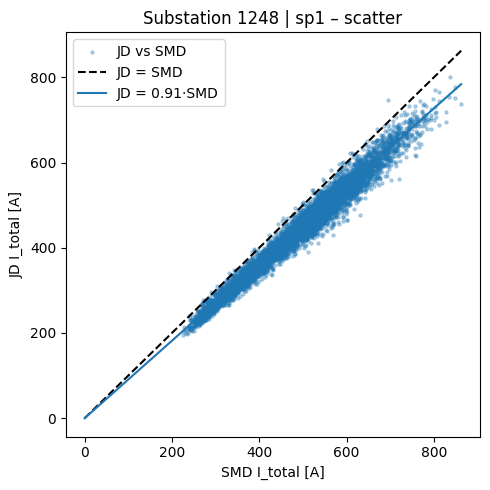

In [15]:
substation_id = 1248
transformer = "sp1"  # or "sp2"

alpha = df_computed.loc[
    (df_computed["substation_id"] == substation_id) &
    (df_computed["transformer"] == transformer),
    "alpha_ls"
].values[0]

plot_substation_scatter(
    merged=df_merged,
    sid=substation_id,
    transformer=transformer,
    alpha=alpha,
)


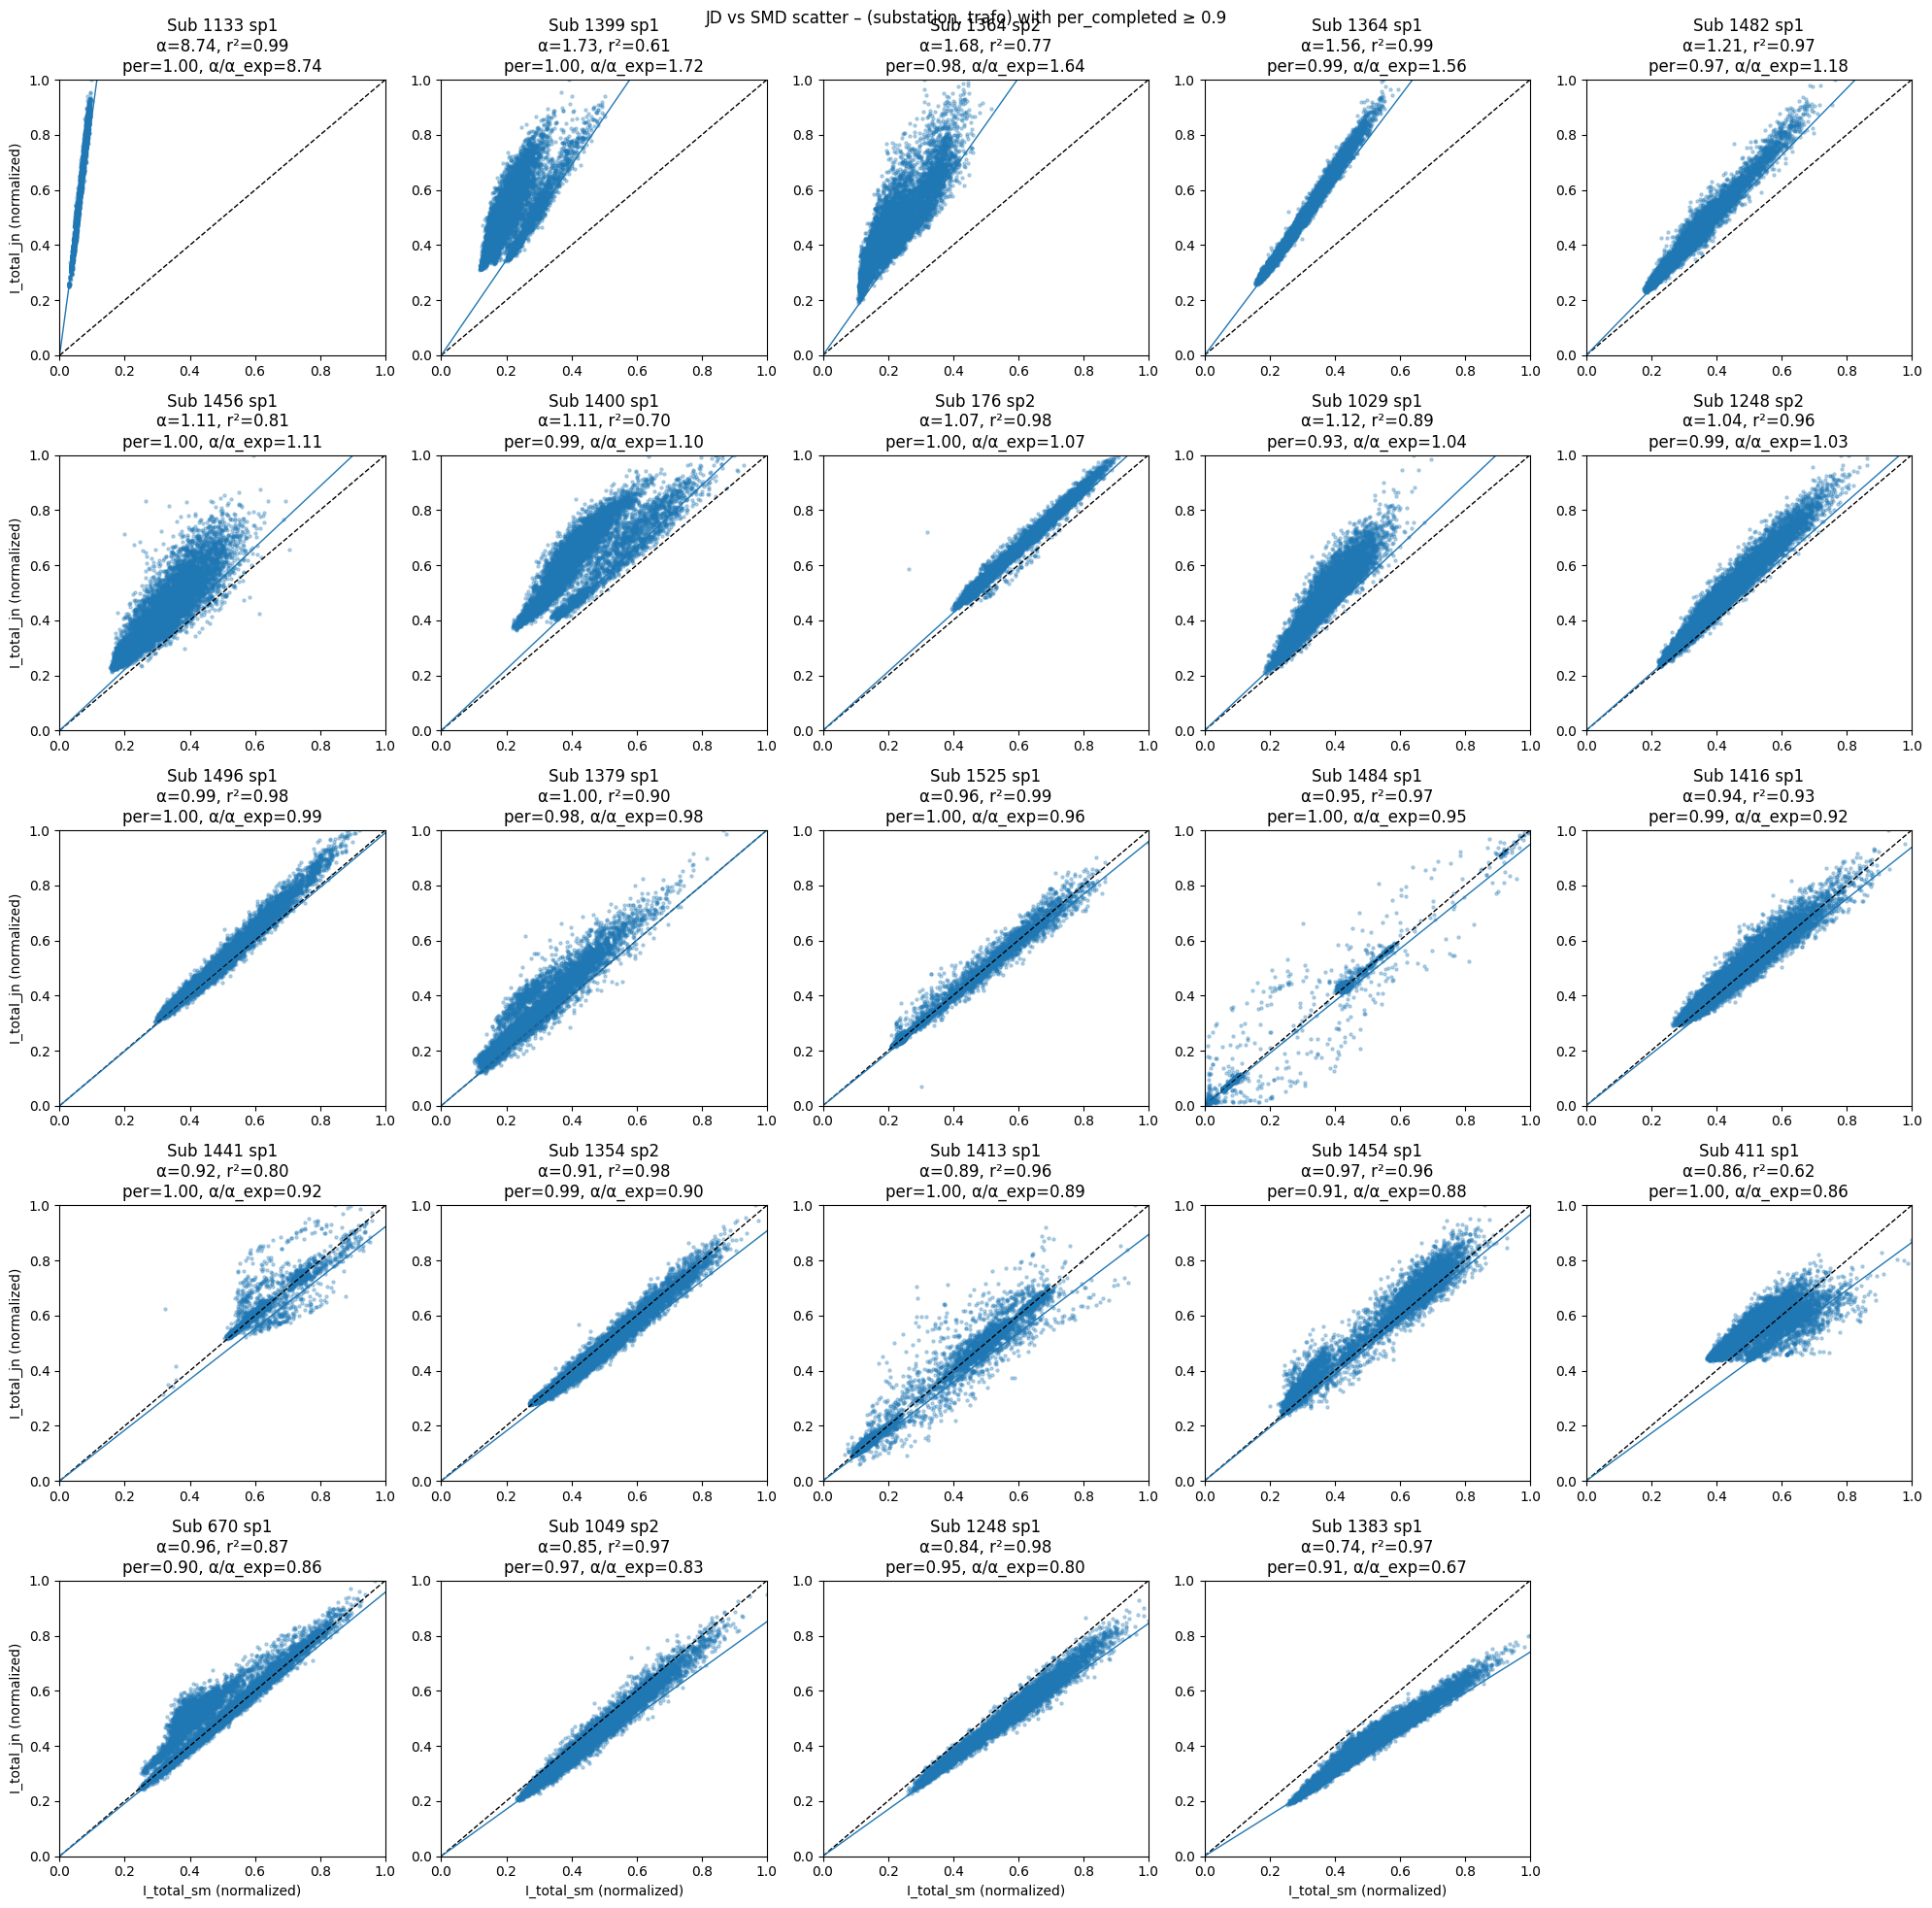

In [18]:
plot_scatter_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.9,
    max_plots=24,
    cols=5,
)


In [46]:

df = df_merged.copy()

# --- coverage adjustment ---
df["per_completed"] = pd.to_numeric(df["per_completed"], errors="coerce")
mask_pct = df["per_completed"] > 1.5
df.loc[mask_pct, "per_completed"] = df.loc[mask_pct, "per_completed"] / 100.0
df.loc[(df["per_completed"] <= 0) | (df["per_completed"] > 1.0), "per_completed"] = np.nan

df["I_total_sm_adj"] = df["I_total_sm"] / df["per_completed"]
df.loc[~np.isfinite(df["I_total_sm_adj"]), "I_total_sm_adj"] = np.nan

# --- regression filters ---
min_current = 5.0
min_per_completed = 0.90
min_points = 8000

df_reg = df[
    (df["I_total_sm"].abs() > min_current) &
    (df["I_total_jn"].abs() > min_current) &
    (df["per_completed"] >= min_per_completed) &
    (df["I_total_sm_adj"] > 0) &
    np.isfinite(df["I_total_sm_adj"]) &
    np.isfinite(df["I_total_jn"])
].copy()

print("df_reg shape:", df_reg.shape)
print("Unique (sub,trafo):", df_reg.groupby(["substation_id","transformer"]).ngroups)

# group sizes (sanity)
gsize = df_reg.groupby(["substation_id","transformer"]).size().sort_values(ascending=False)
display(gsize.head(10))
print("Groups with < min_points:", (gsize < min_points).sum(), "/", len(gsize))


df_reg shape: (272485, 18)
Unique (sub,trafo): 33


substation_id  transformer
1383           sp1            8832
1248           sp1            8832
1399           sp1            8832
411            sp1            8832
1364           sp2            8832
1248           sp2            8832
1364           sp1            8832
1133           sp1            8832
1049           sp2            8832
1029           sp1            8832
dtype: int64

Groups with < min_points: 4 / 33


In [49]:
# Try statsmodels quantile regression; if unavailable we fall back to ratio-quantile.
try:
    import statsmodels.api as sm
    HAVE_SM = True
except Exception as e:
    HAVE_SM = False
    print("statsmodels not available -> will use ratio-quantile fallback.")
    print("Error:", e)

def fit_k_quantile_per_group(df_reg: pd.DataFrame, tau: float = 0.10, min_points: int = 200):
    rows = []
    for (sid, tr), g in df_reg.groupby(["substation_id", "transformer"]):
        if len(g) < min_points:
            continue

        x = g["I_total_sm_adj"].to_numpy(dtype=float)
        y = g["I_total_jn"].to_numpy(dtype=float)

        # require positive x for regression stability
        m = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[m]; y = y[m]
        if len(x) < min_points:
            continue

        # --- shape sanity ---
        corr_xy = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan

        # --- physics sanity (raw): how often does SM_adj exceed Janitza? ---
        # This should be near 0 if mapping + scaling are consistent.
        frac_x_gt_y = float(np.mean(x > y))

        per = float(g["per_completed"].iloc[0])

        if HAVE_SM:
            X = sm.add_constant(x)  # [1, x]
            try:
                mod = sm.QuantReg(y, X)
                res = mod.fit(q=tau, max_iter=2000)
                b = float(res.params[0])
                k = float(res.params[1])
            except Exception:
                # if solver struggles, fall back to ratio-quantile
                r = y / x
                k = float(np.nanquantile(r, tau))
                b = 0.0
        else:
            # fallback: quantile of ratios (no intercept)
            r = y / x
            k = float(np.nanquantile(r, tau))
            b = 0.0

        # Diagnostics: negative residual fraction (physics check)
        yhat = b + k * x
        resid = y - yhat
        frac_neg = float(np.mean(resid < -1e-6))  # tolerance

        # OLS R^2 as a "shape similarity" sanity (optional)
        # (not used for estimation, just reporting)
        try:
            k_ols, b_ols = np.polyfit(x, y, 1)
            y_pred = k_ols * x + b_ols
            ss_res = np.sum((y - y_pred)**2)
            ss_tot = np.sum((y - y.mean())**2)
            r2_ols = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        except Exception:
            r2_ols = np.nan

        rows.append({
            "substation_id": sid,
            "transformer": tr,
            "tau": tau,
            "k_hat": k,
            "b_hat": b,
            "corr_xy": corr_xy,
            "frac_x_gt_y": frac_x_gt_y,
            "per_completed": per,
            "n_points": int(len(x)),
            "frac_neg_resid": frac_neg,
            "r2_ols": r2_ols,
            "k_hat_log10": np.log10(k) if (k is not None and np.isfinite(k) and k > 0) else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["k_hat"], ascending=False)

def detect_transformer_swaps(df_reg, min_points=2000, corr_gain=0.05):
    """
    For substations that have BOTH sp1 and sp2, compare:
      corr(sp1 SM_adj, sp1 JN) vs corr(sp1 SM_adj, sp2 JN)
      corr(sp2 SM_adj, sp2 JN) vs corr(sp2 SM_adj, sp1 JN)

    If both cross-correlations beat the same-transformer correlations by corr_gain,
    flag as swap_suspect.
    """
    out = []
    need = ["substation_id", "transformer", "ts", "I_total_sm_adj", "I_total_jn"]
    for c in need:
        if c not in df_reg.columns:
            raise KeyError(f"detect_transformer_swaps: df_reg missing {c}")

    for sid, gs in df_reg.groupby("substation_id"):
        trafos = set(gs["transformer"].astype(str).str.lower().unique())
        if not {"sp1", "sp2"}.issubset(trafos):
            continue

        g1 = gs[gs["transformer"].str.lower() == "sp1"][["ts","I_total_sm_adj","I_total_jn"]].rename(
            columns={"I_total_sm_adj":"x1","I_total_jn":"y1"}
        )
        g2 = gs[gs["transformer"].str.lower() == "sp2"][["ts","I_total_sm_adj","I_total_jn"]].rename(
            columns={"I_total_sm_adj":"x2","I_total_jn":"y2"}
        )

        h = g1.merge(g2, on="ts", how="inner")
        if len(h) < min_points:
            continue

        c11 = h["x1"].corr(h["y1"])  # sp1 with sp1
        c22 = h["x2"].corr(h["y2"])  # sp2 with sp2
        c12 = h["x1"].corr(h["y2"])  # sp1 with sp2 (cross)
        c21 = h["x2"].corr(h["y1"])  # sp2 with sp1 (cross)

        best_same = np.nanmax([c11, c22])
        best_cross = np.nanmax([c12, c21])

        swap = (c12 > c11 + corr_gain) and (c21 > c22 + corr_gain)

        out.append({
            "substation_id": sid,
            "n_points_pair": int(len(h)),
            "corr_sp1": float(c11) if pd.notna(c11) else np.nan,
            "corr_sp2": float(c22) if pd.notna(c22) else np.nan,
            "corr_cross_1to2": float(c12) if pd.notna(c12) else np.nan,
            "corr_cross_2to1": float(c21) if pd.notna(c21) else np.nan,
            "best_same": float(best_same) if pd.notna(best_same) else np.nan,
            "best_cross": float(best_cross) if pd.notna(best_cross) else np.nan,
            "gain_cross_minus_same": float(best_cross - best_same) if pd.notna(best_same) and pd.notna(best_cross) else np.nan,
            "swap_suspect": bool(swap),
        })

    return pd.DataFrame(out).sort_values("gain_cross_minus_same", ascending=False)


df_k = fit_k_quantile_per_group(df_reg, tau=0.10, min_points=min_points)
print("Estimated k for groups:", len(df_k))

swap_df = detect_transformer_swaps(df_reg, min_points=min_points, corr_gain=0.05)
display(swap_df.head(20))
print("Swap suspects:", int(swap_df["swap_suspect"].sum()))


# Look at distribution of k
display(df_k[["k_hat","frac_neg_resid","per_completed","n_points"]].describe())

# Top 10 largest k (likely CT/mapping issues)
display(df_k.sort_values("k_hat", ascending=False).head(10))

# Any groups where model violates physics a lot (many negative residuals)
display(df_k.sort_values("frac_neg_resid", ascending=False).head(10))

df_k["bad_shape"] = (df_k["corr_xy"] < 0.8) | (df_k["r2_ols"] < 0.6)
df_k["bad_physics"] = (df_k["frac_x_gt_y"] > 0.05)  # tune threshold

display(df_k[df_k["bad_shape"] | df_k["bad_physics"]].sort_values(["bad_physics","bad_shape"], ascending=False).head(30))


df_corr = df_reg.merge(
    df_k[["substation_id","transformer","k_hat","b_hat"]],
    on=["substation_id","transformer"],
    how="left",
)

# Fill missing k with 1 (no correction) for groups not fitted
df_corr["k_hat"] = df_corr["k_hat"].fillna(1.0)

# Correct ONLY scaling (recommended)
df_corr["I_total_jn_corr"] = df_corr["I_total_jn"] / df_corr["k_hat"]

# Unmetered/NTL-ish indicator (after correction and coverage adjustment)
df_corr["Delta"] = df_corr["I_total_jn_corr"] - df_corr["I_total_sm_adj"]

print(df_corr[["I_total_sm","I_total_sm_adj","I_total_jn","I_total_jn_corr","Delta"]].describe())



Estimated k for groups: 29


,substation_id,n_points_pair,corr_sp1,corr_sp2,corr_cross_1to2,corr_cross_2to1,best_same,best_cross,gain_cross_minus_same,swap_suspect
2,1534,8802,0.584425,0.818386,0.570157,0.840740,0.818386,0.840740,0.022354,False
0,1248,8832,0.988614,0.981274,0.831525,0.768217,0.988614,0.831525,-0.157089,False
1,1364,8832,0.993884,0.879065,0.753776,0.660130,0.993884,0.753776,-0.240108,False


Swap suspects: 0


,k_hat,frac_neg_resid,per_completed,n_points
count,29.000000,29.000000,29.000000,29.000000
mean,1.116536,0.099961,0.981907,8805.827586
std,1.687842,0.000060,0.028863,74.415373
min,0.002301,0.099864,0.902357,8480.000000
25%,0.576870,0.099898,0.977273,8817.000000
50%,0.898028,0.099977,0.996063,8831.000000
75%,1.041578,0.099989,1.000000,8832.000000
max,9.671024,0.100116,1.000000,8832.000000


,substation_id,transformer,tau,k_hat,b_hat,corr_xy,frac_x_gt_y,per_completed,n_points,frac_neg_resid,r2_ols,k_hat_log10
6,1133,sp1,0.1,9.671024,-673.687556,0.995575,0.000000,1.000000,8832,0.099977,0.991169,0.985472
10,1364,sp1,0.1,1.663052,-58.438444,0.993884,0.000000,0.994859,8832,0.099977,0.987806,0.220906
11,1364,sp2,0.1,1.359942,75.046368,0.879065,0.000000,0.977778,8832,0.099977,0.772755,0.133520
4,1029,sp1,0.1,1.194420,-58.275851,0.942600,0.010983,0.930233,8832,0.099864,0.888495,0.077157
22,1482,sp1,0.1,1.189162,1.568010,0.983471,0.000000,0.971429,8830,0.099887,0.967215,0.075241
8,1248,sp2,0.1,1.124289,-25.454311,0.981274,0.009624,0.994709,8832,0.099977,0.962898,0.050878
0,176,sp2,0.1,1.089997,-8.630821,0.992223,0.005672,1.000000,8816,0.100045,0.984506,0.037425
16,1399,sp1,0.1,1.041578,284.798156,0.779083,0.000000,0.996063,8832,0.099977,0.606970,0.017692
24,1496,sp1,0.1,1.036579,-16.213942,0.989732,0.082559,1.000000,8830,0.100000,0.979570,0.015603
12,1379,sp1,0.1,1.002091,0.602578,0.950801,0.080413,0.977273,8817,0.099921,0.904022,0.000907


,substation_id,transformer,tau,k_hat,b_hat,corr_xy,frac_x_gt_y,per_completed,n_points,frac_neg_resid,r2_ols,k_hat_log10
15,1398,sp2,0.1,0.002301,6.369581,0.052663,0.910673,1.000000,8620,0.100116,0.002773,-2.638003
18,1413,sp1,0.1,0.870619,49.235625,0.981872,0.435743,1.000000,8785,0.100057,0.964072,-0.060172
0,176,sp2,0.1,1.089997,-8.630821,0.992223,0.005672,1.000000,8816,0.100045,0.984506,0.037425
26,1528,sp1,0.1,0.335658,8.620465,0.853560,0.168868,1.000000,8480,0.100000,0.728565,-0.474103
24,1496,sp1,0.1,1.036579,-16.213942,0.989732,0.082559,1.000000,8830,0.100000,0.979570,0.015603
9,1354,sp2,0.1,0.903952,5.598836,0.988493,0.785189,0.992509,8831,0.099989,0.977118,-0.043854
21,1457,sp2,0.1,0.410925,13.756917,0.892240,0.178123,1.000000,8831,0.099989,0.796093,-0.386238
19,1416,sp1,0.1,0.868926,32.175635,0.966185,0.347299,0.985437,8831,0.099989,0.933513,-0.061017
1,411,sp1,0.1,0.354021,138.628839,0.786395,0.248641,1.000000,8832,0.099977,0.618416,-0.450971
13,1383,sp1,0.1,0.716129,-30.978530,0.983549,1.000000,0.905192,8832,0.099977,0.967369,-0.145009


,substation_id,transformer,tau,k_hat,b_hat,corr_xy,frac_x_gt_y,per_completed,n_points,frac_neg_resid,r2_ols,k_hat_log10,bad_shape,bad_physics
1,411,sp1,0.1,0.354021,138.628839,0.786395,0.248641,1.000000,8832,0.099977,0.618416,-0.450971,True,True
14,1394,sp2,0.1,0.183191,368.408638,0.418219,0.999773,1.000000,8829,0.099898,0.174907,-0.737096,True,True
27,1534,sp1,0.1,0.120791,153.023067,0.583955,0.975366,1.000000,8809,0.099898,0.341004,-0.917964,True,True
15,1398,sp2,0.1,0.002301,6.369581,0.052663,0.910673,1.000000,8620,0.100116,0.002773,-2.638003,True,True
24,1496,sp1,0.1,1.036579,-16.213942,0.989732,0.082559,1.000000,8830,0.100000,0.979570,0.015603,False,True
12,1379,sp1,0.1,1.002091,0.602578,0.950801,0.080413,0.977273,8817,0.099921,0.904022,0.000907,False,True
23,1484,sp1,0.1,0.955642,1.312319,0.987190,0.168197,1.000000,8823,0.099966,0.974545,-0.019705,False,True
25,1525,sp1,0.1,0.911346,32.692486,0.993289,0.234288,1.000000,8831,0.099875,0.986624,-0.040317,False,True
9,1354,sp2,0.1,0.903952,5.598836,0.988493,0.785189,0.992509,8831,0.099989,0.977118,-0.043854,False,True
5,1049,sp2,0.1,0.898028,-12.450470,0.986429,0.973732,0.970760,8832,0.099977,0.973042,-0.046710,False,True


          I_total_sm  I_total_sm_adj     I_total_jn  I_total_jn_corr  \
count  272485.000000   272485.000000  272485.000000     2.724850e+05   
mean      560.901381      571.855454     795.761788     2.817179e+03   
std       550.300957      553.848002    1735.660581     3.444112e+04   
min         5.500000        5.500000       5.005120     5.080160e+00   
25%       220.670000      223.598864     238.758644     3.140796e+02   
50%       425.210000      436.374750     453.017092     5.778368e+02   
75%       709.025000      723.165000     714.938545     8.592574e+02   
max      7772.000000     7772.000000   19345.116699     1.832564e+06   

              Delta  
count  2.724850e+05  
mean   2.245323e+03  
std    3.443195e+04  
min   -4.070046e+03  
25%    3.449077e+00  
50%    3.556639e+01  
75%    2.191087e+02  
max    1.832516e+06  


In [ ]:
# distribution + outliers
display(df_k["k_hat"].describe())

# flag implausible k (tune thresholds)
k_lo, k_hi = 0.5, 3.0
outliers = df_k[(df_k["k_hat"] < k_lo) | (df_k["k_hat"] > k_hi)].copy()
display(outliers.sort_values("k_hat", ascending=False))

print("n groups:", len(df_k))
print("n outliers:", len(outliers))

# I should look into the bad shape and pysic columns to see if I should tune the values and how they are computed but for now I will countine.

count    29.000000
mean      1.116536
std       1.687842
min       0.002301
25%       0.576870
50%       0.898028
75%       1.041578
max       9.671024
Name: k_hat, dtype: float64

,substation_id,transformer,tau,k_hat,b_hat,corr_xy,frac_x_gt_y,per_completed,n_points,frac_neg_resid,r2_ols,k_hat_log10,bad_shape,bad_physics
6,1133,sp1,0.1,9.671024,-673.687556,0.995575,0.000000,1.0,8832,0.099977,0.991169,0.985472,False,False
21,1457,sp2,0.1,0.410925,13.756917,0.892240,0.178123,1.0,8831,0.099989,0.796093,-0.386238,False,True
1,411,sp1,0.1,0.354021,138.628839,0.786395,0.248641,1.0,8832,0.099977,0.618416,-0.450971,True,True
26,1528,sp1,0.1,0.335658,8.620465,0.853560,0.168868,1.0,8480,0.100000,0.728565,-0.474103,False,True
14,1394,sp2,0.1,0.183191,368.408638,0.418219,0.999773,1.0,8829,0.099898,0.174907,-0.737096,True,True
27,1534,sp1,0.1,0.120791,153.023067,0.583955,0.975366,1.0,8809,0.099898,0.341004,-0.917964,True,True
15,1398,sp2,0.1,0.002301,6.369581,0.052663,0.910673,1.0,8620,0.100116,0.002773,-2.638003,True,True


n groups: 29
n outliers: 7


points: 922
ratio describe:


count    922.000000
mean       0.499384
std        0.933885
min        0.007813
1%         0.010319
5%         0.094527
10%        0.113630
50%        0.329254
90%        1.174120
95%        1.218596
99%        1.348814
max       19.698594
Name: ratio, dtype: float64

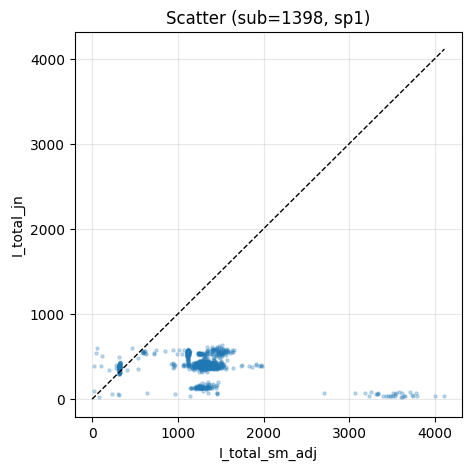

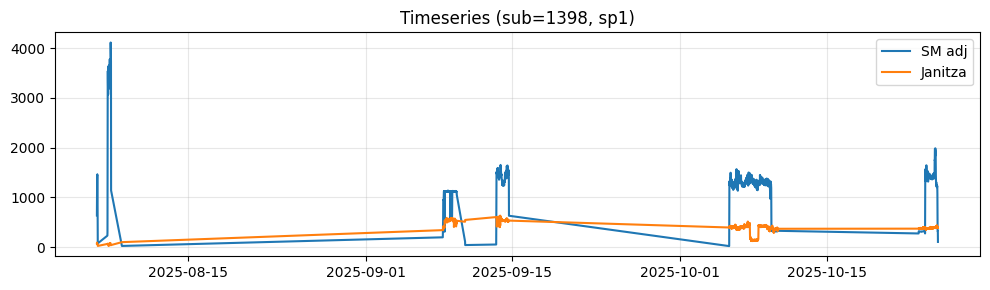

In [44]:
sid, tr = 1398, "sp1"
g = df_reg[(df_reg["substation_id"] == sid) & (df_reg["transformer"] == tr)].copy()
g = g.sort_values("ts")

g["ratio"] = g["I_total_jn"] / g["I_total_sm_adj"]

print("points:", len(g))
print("ratio describe:")
display(g["ratio"].describe(percentiles=[0.01,0.05,0.1,0.5,0.9,0.95,0.99]))

# scatter
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.scatter(g["I_total_sm_adj"], g["I_total_jn"], s=5, alpha=0.25)
mx = max(g["I_total_sm_adj"].max(), g["I_total_jn"].max())
plt.plot([0,mx],[0,mx],"k--",lw=1)
plt.title(f"Scatter (sub={sid}, {tr})")
plt.xlabel("I_total_sm_adj")
plt.ylabel("I_total_jn")
plt.grid(alpha=0.3)
plt.show()

# timeseries
plt.figure(figsize=(10,3))
plt.plot(g["ts"], g["I_total_sm_adj"], label="SM adj")
plt.plot(g["ts"], g["I_total_jn"], label="Janitza")
plt.title(f"Timeseries (sub={sid}, {tr})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


                            MAE_Before     MAE_After  WAPE_Before  \
substation_id transformer                                           
1398          sp1           384.475758   3457.840118   302.077721   
              sp2           464.636374  11241.521023   103.832445   
1554          sp1           162.680956    795.473021    53.336255   
1457          sp2            25.511978    185.483562    24.199955   
1534          sp1          1189.486060   2877.831616    59.885534   

                            WAPE_After  RMSE_Before    RMSE_After  n_mps  
substation_id transformer                                                 
1398          sp1          2716.781076   489.737761   3906.910234      1  
              sp2          2512.146439   562.342895  37273.373713      1  
1554          sp1           260.802204   293.466289   1411.257845      2  
1457          sp2           175.944565    47.679214    261.364124      1  
1534          sp1           144.886509  1608.253387   3485.148059 

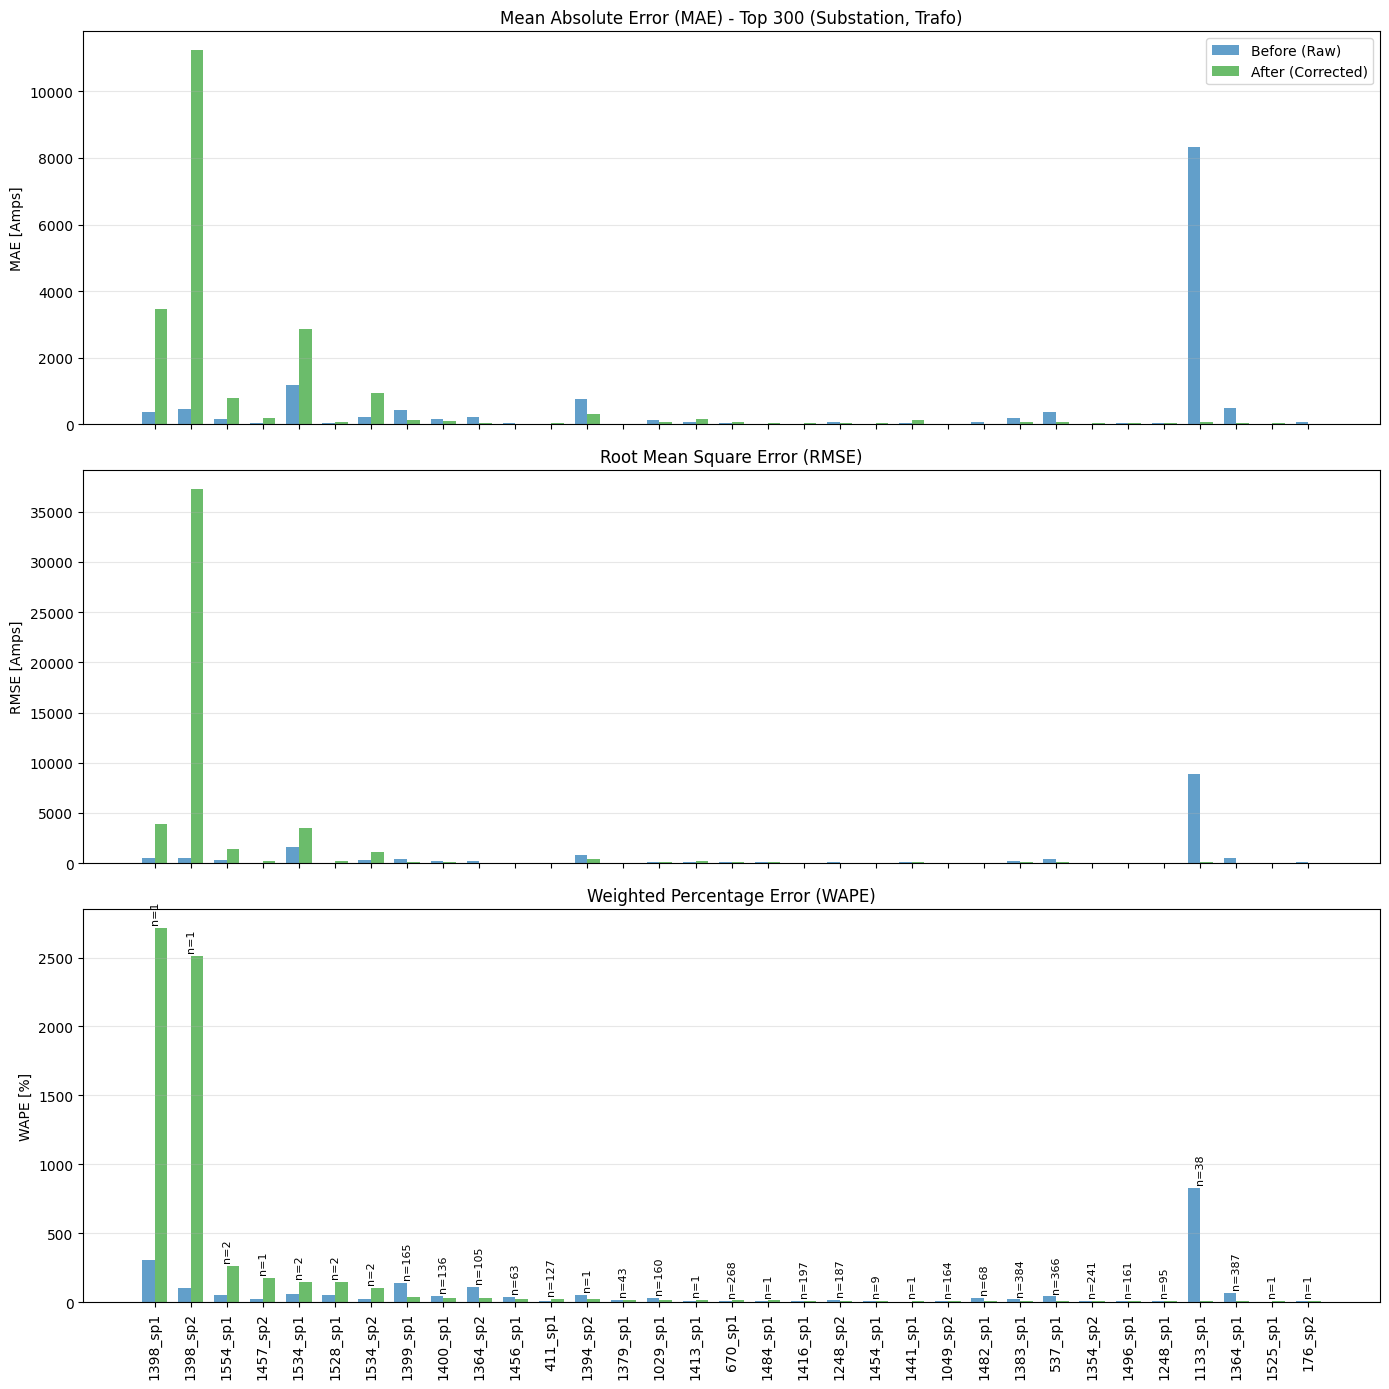

In [20]:

# ==========================================
# 1. PREPARE DATA (Merged only, no correction yet)
# ==========================================
df_metrics_before = calculate_robust_metrics( df_merged,sm_col="I_total_sm",jn_col="I_total_jn")

# ==========================================
# 2. APPLY CORRECTION & RE-CALCULATE
# ==========================================
df_after = df_merged.copy()

df_after = df_after.merge(
    df_computed[["substation_id", "transformer", "alpha_ct"]],
    on=["substation_id", "transformer"],
    how="left",
)

df_after["alpha_ct"] = df_after["alpha_ct"].fillna(1.0)

# Correct Janitza
df_after["I_total_jn_corr"] = df_after["I_total_jn"] / df_after["alpha_ct"]

# Calculate metrics on corrected data
df_metrics_after = calculate_robust_metrics(
    df_after, 
    sm_col="I_total_sm", 
    jn_col="I_total_jn_corr"
)

# ==========================================
# 3. COMBINE & FILTER
# ==========================================
cutoff = 0.9
min_num = 1

# Filter Index based on coverage
valid_ids = df_metrics_before[
    (df_metrics_before["per_completed"] >= cutoff) & 
    (df_metrics_before["n_mps"] >= min_num)
].index

# Select valid rows
stats_final = pd.DataFrame({
    "MAE_Before": df_metrics_before.loc[valid_ids, "MAE"],
    "MAE_After":  df_metrics_after.loc[valid_ids, "MAE"],
    
    "WAPE_Before": df_metrics_before.loc[valid_ids, "WAPE"],
    "WAPE_After":  df_metrics_after.loc[valid_ids, "WAPE"],
    
    "RMSE_Before": df_metrics_before.loc[valid_ids, "RMSE"],
    "RMSE_After":  df_metrics_after.loc[valid_ids, "RMSE"],
    
    "n_mps": df_metrics_before.loc[valid_ids, "n_mps"]
})

# Sort by Improved WAPE
stats_final = stats_final.sort_values("WAPE_After", ascending=False)

print(stats_final.head())


plot_robust_comparison(stats_final)



Change in the ratio of SMD vs Janitza and after correction

Ratio can be misleading here are stations ploted with old smart meter current and corrected.

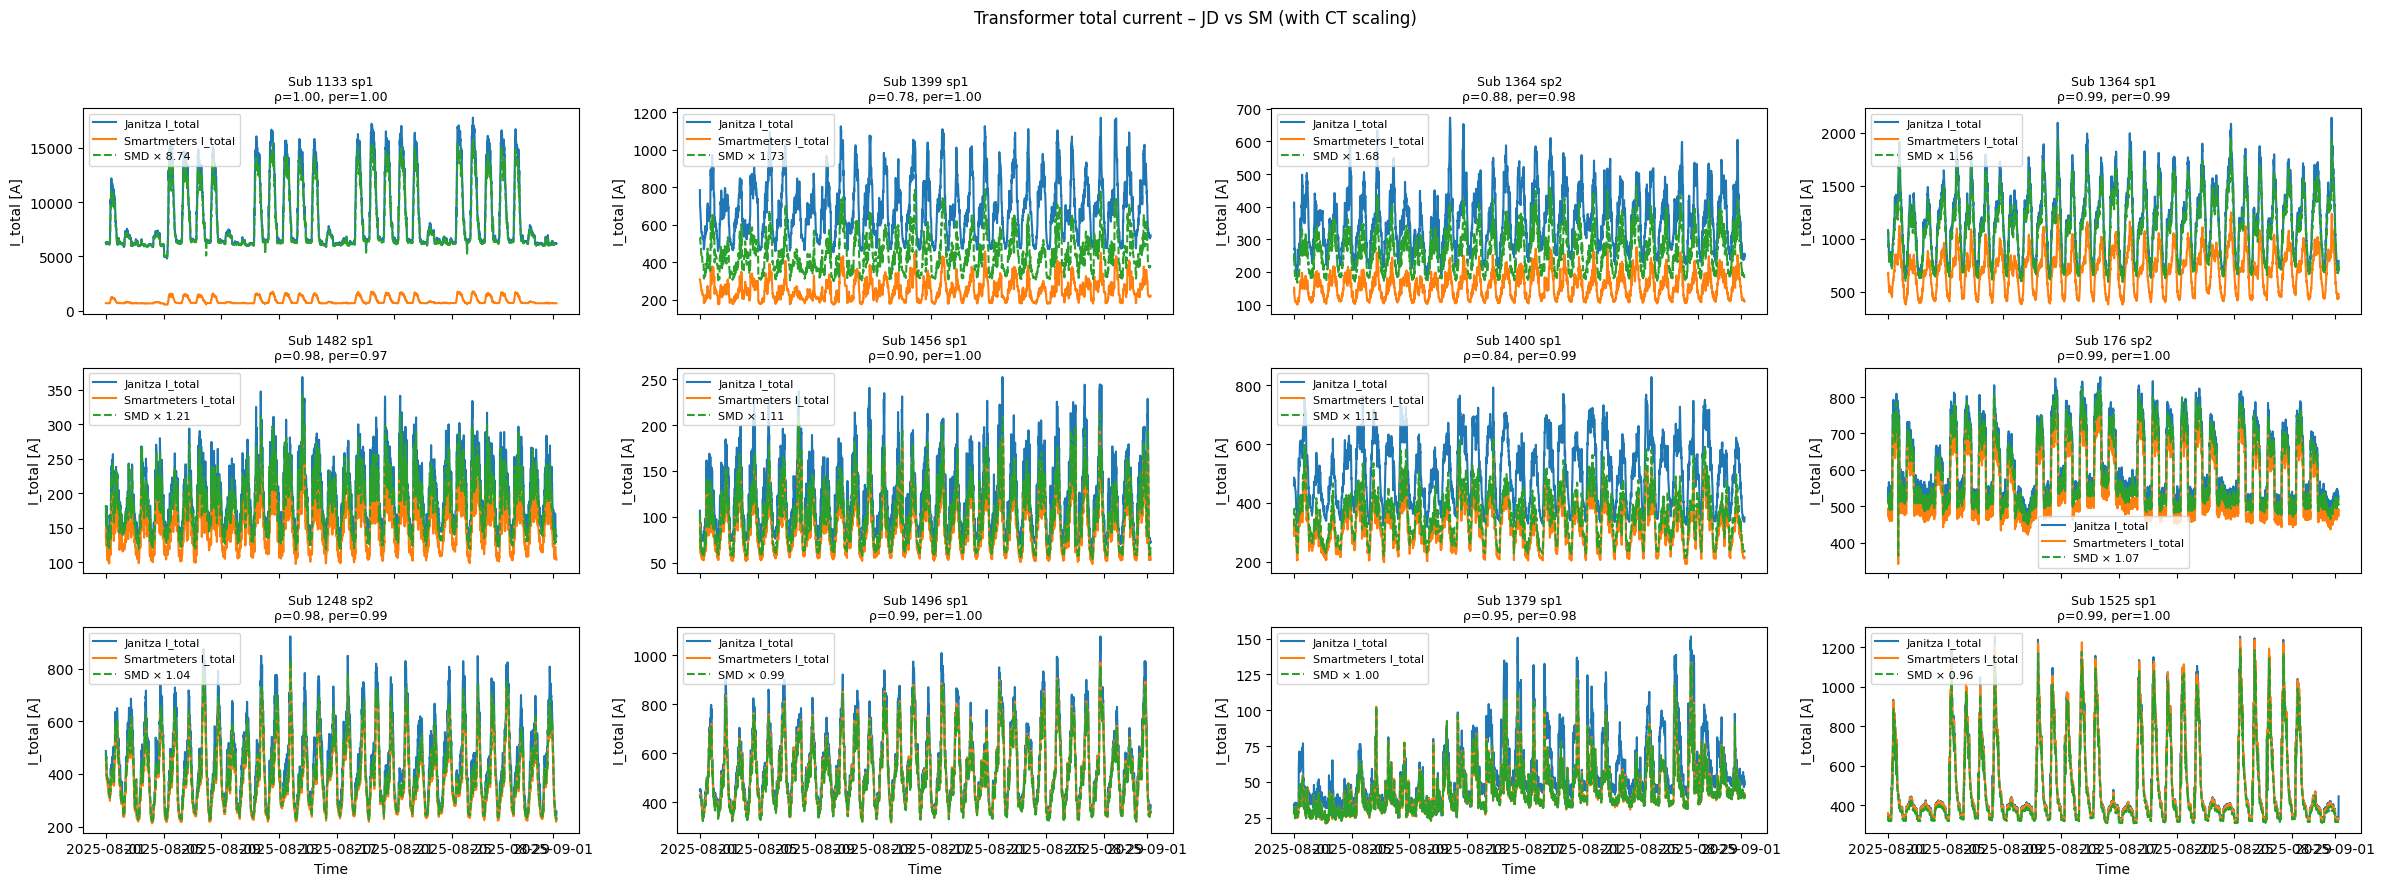

In [22]:
plot_substation_timeseries_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.96,
    max_plots=12,
    cols=4,
    max_points=3000,
)